In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [2]:
bronx_matched = pd.read_csv('../data/processed/bronx_matched_clustered.csv')
bronx_matched['crash_date'] = pd.to_datetime(bronx_matched['crash_date'])

In [3]:
injured_weight = 20
killed_weight = 300

bronx_matched['severity_weight'] = (
    1
    + (injured_weight * bronx_matched['number_of_persons_injured'])
    + (killed_weight * bronx_matched['number_of_persons_killed'])
)

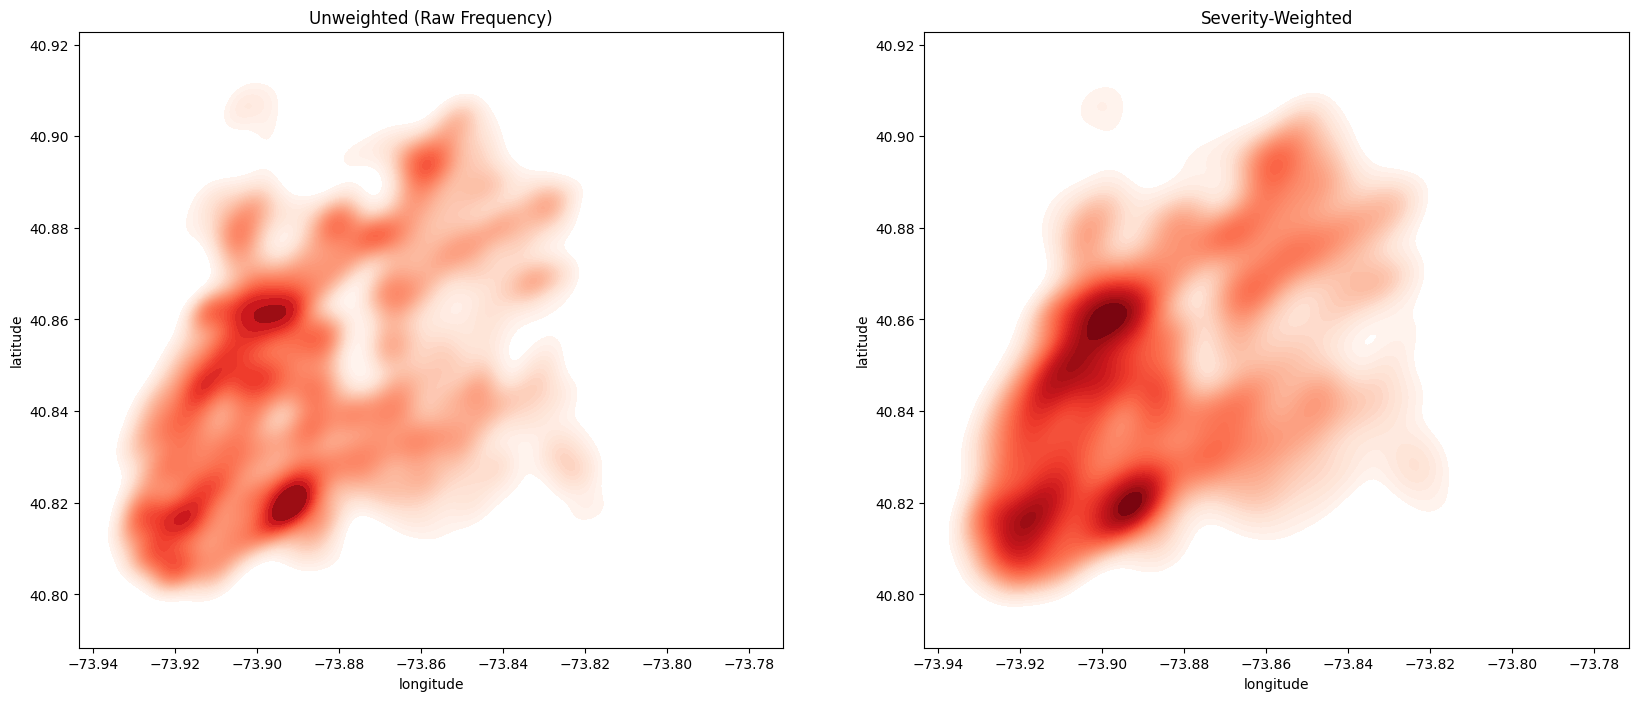

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.kdeplot(data=bronx_matched, x='longitude', y='latitude', cmap='Reds', fill=True, thresh=0.05, levels=50, ax=axes[0])
axes[0].set_title('Unweighted (Raw Frequency)')

sns.kdeplot(data=bronx_matched, x='longitude', y='latitude', weights='severity_weight', cmap='Reds', fill=True, thresh=0.05, levels=50, ax=axes[1])
axes[1].set_title('Severity-Weighted')

plt.show()

In [9]:
print(bronx_matched['severity_weight'].sum())
print(len(bronx_matched))

637957.0
225012


In [8]:
lons = bronx_matched['longitude'].values
lats = bronx_matched['latitude'].values
weights = bronx_matched['severity_weight'].values

kde = gaussian_kde(np.vstack([lons, lats]), weights=weights)

In [9]:
grid_size = 100  # res
lon_min, lon_max = lons.min(), lons.max()
lat_min, lat_max = lats.min(), lats.max()

lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, grid_size),
    np.linspace(lat_min, lat_max, grid_size)
)

grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

In [10]:
density = kde(grid_coords).reshape(grid_size, grid_size)

In [15]:
density_normalized = (density - density.min()) / (density.max() - density.min())
density_normalized

array([[3.72411244e-02, 5.10347787e-02, 6.73490139e-02, ...,
        3.46793091e-06, 1.39117262e-06, 4.99981637e-07],
       [5.38602679e-02, 7.30862432e-02, 9.56237562e-02, ...,
        7.47448097e-06, 3.11712308e-06, 1.16465551e-06],
       [7.47151397e-02, 1.00529736e-01, 1.30331598e-01, ...,
        1.48238282e-05, 6.42669234e-06, 2.49630327e-06],
       ...,
       [2.29942007e-09, 1.25217729e-08, 6.18709090e-08, ...,
        1.77915052e-11, 1.32098199e-11, 1.03890720e-11],
       [9.55716951e-10, 5.47596022e-09, 2.84481930e-08, ...,
        3.96460663e-12, 2.64264168e-12, 1.88995231e-12],
       [3.75290387e-10, 2.26314801e-09, 1.23581580e-08, ...,
        5.57960830e-13, 1.95868463e-13, 0.00000000e+00]], shape=(100, 100))

In [17]:
heatmap_points = []
for i in range(grid_size):
    for j in range(grid_size):
        heatmap_points.append({
            'lat': float(lat_grid[i, j]),
            'lon': float(lon_grid[i, j]),
            'intensity': float(density_normalized[i, j])
        })

heatmap_df = pd.DataFrame(heatmap_points)
heatmap_df.to_csv('../data/processed/bronx_density_heatmap.csv', index=False)

print(heatmap_df.head())
print(heatmap_df.shape)

        lat       lon  intensity
0  40.79828 -73.93224   0.037241
1  40.79828 -73.93073   0.051035
2  40.79828 -73.92922   0.067349
3  40.79828 -73.92771   0.085188
4  40.79828 -73.92620   0.102704
(10000, 3)


In [18]:
heatmap_df['intensity'].describe()

count    10000.000000
mean         0.206820
std          0.234798
min          0.000000
25%          0.007033
50%          0.106030
75%          0.362448
max          1.000000
Name: intensity, dtype: float64